In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.interpolate import CubicSpline

In [2]:
# Define linear interpolation function
# This function finds the y value for a given x within the given range of x_pnts using linear interpolation.
# Function assumes that the provided x_pnts are pre-sorted from lowest to highest
# Resolution can be increased by giving how many n points are desired between points in the given data set.
def lin_interpolate(x_pnts, y_pnts, x, n = 1):
    if(len(x_pnts) != len(y_pnts)): #Check to see if given x array and y array are equal length, otherwise exit
        print("Error: Length of x_pnts and y_pnts do not match. Values returned.")
        return x, x_pnts, y_pnts
    
    x_array = np.array([]) # Initialize output x array
    y_array = np.array([]) # Initialize output y array
    g = -1 # Initialize output y value

    if(n == 1): # If resolution is default value, output the given arrays
        x_array = x_pnts
        y_array = y_pnts
    else:
        for i in range(0, len(x_pnts) - 1):
            xarr = np.array([]) # Arrays used between each set of points
            yarr = np.array([])
            xi = x_pnts[i]
            xi1 = x_pnts[i+1]
            yi = y_pnts[i]
            yi1 = y_pnts[i+1]

            xarr = np.linspace(xi, xi1, n) # Evenly spaced points between given x values
            x_array = np.append(x_array, xarr)

            a = (yi1 - yi) / (xi1 - xi)
            b = yi - (a * xi)
            yarr = (a * xarr) + b # Calculate straight line between two points
            y_array = np.append(y_array, yarr)

    if(x >= x_pnts[0] and x <= x_pnts[-1]): # Check if requested x is within the given x range
        for i in range(0, len(x_pnts)): # Find which two given points the requested x is between
            if(x >= x_pnts[i] and x <= x_pnts[i+1]):
                xi = x_pnts[i]
                xi1 = x_pnts[i+1]
                yi = y_pnts[i]
                yi1 = y_pnts[i+1]
                print("x =", x, "falls between x =", xi, "and x =", xi1)
                break
        a = (yi1 - yi) / (xi1 - xi)
        b = yi
        g = a * (x - xi) + b # Calculate y on line between the two given points the requested x is between
    else:
        print("x =", x, "falls outside of the given data range. Interpolated arrays and x value returned.")
        return x, x_array, y_array
    return g, x_array, y_array

In [3]:
# Read data from HW_01.txt
xpoints, ypoints = np.loadtxt('HW01_data.txt', skiprows=1, usecols=(0, 1), unpack=True)
print("x array:", xpoints)
print("y array:", ypoints)

x array: [-1.   0.   1.   2.   3.   3.5  5.   6.   7.   8. ]
y array: [-3. -1.  1.  3.  3.  1.  4.  2.  1.  1.]


In [4]:
# Declare desired x value, resolution, and use interpolation function
pnt = 2.5
num = 10
g_val, highResX, highResY = lin_interpolate(xpoints, ypoints, pnt, num)
np.set_printoptions(precision=2, suppress=True, floatmode='fixed')
print("The y value at x =", pnt, "is", g_val)
print("The interpolated x array is:", highResX)
print("The interpolated y array is:", highResY)
print("Length of interpolated x array:", len(highResX))
print("Length of interpolated y array:", len(highResY))

x = 2.5 falls between x = 2.0 and x = 3.0
The y value at x = 2.5 is 3.0
The interpolated x array is: [-1.00 -0.89 -0.78 -0.67 -0.56 -0.44 -0.33 -0.22 -0.11  0.00  0.00  0.11
  0.22  0.33  0.44  0.56  0.67  0.78  0.89  1.00  1.00  1.11  1.22  1.33
  1.44  1.56  1.67  1.78  1.89  2.00  2.00  2.11  2.22  2.33  2.44  2.56
  2.67  2.78  2.89  3.00  3.00  3.06  3.11  3.17  3.22  3.28  3.33  3.39
  3.44  3.50  3.50  3.67  3.83  4.00  4.17  4.33  4.50  4.67  4.83  5.00
  5.00  5.11  5.22  5.33  5.44  5.56  5.67  5.78  5.89  6.00  6.00  6.11
  6.22  6.33  6.44  6.56  6.67  6.78  6.89  7.00  7.00  7.11  7.22  7.33
  7.44  7.56  7.67  7.78  7.89  8.00]
The interpolated y array is: [-3.00 -2.78 -2.56 -2.33 -2.11 -1.89 -1.67 -1.44 -1.22 -1.00 -1.00 -0.78
 -0.56 -0.33 -0.11  0.11  0.33  0.56  0.78  1.00  1.00  1.22  1.44  1.67
  1.89  2.11  2.33  2.56  2.78  3.00  3.00  3.00  3.00  3.00  3.00  3.00
  3.00  3.00  3.00  3.00  3.00  2.78  2.56  2.33  2.11  1.89  1.67  1.44
  1.22  1.00  1.00  1.33  1.6

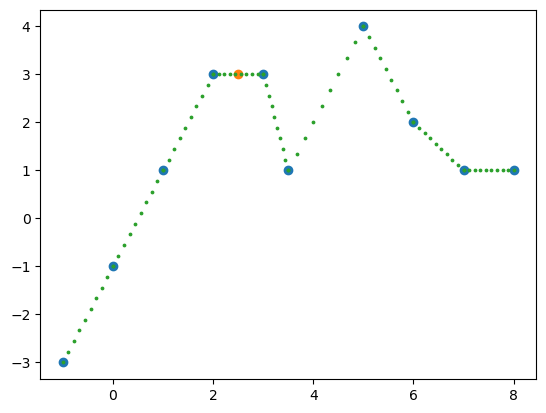

In [5]:
# Plot original data, interpolated data, and point of interest
plt.scatter(xpoints, ypoints)
plt.scatter(pnt, g_val)
plt.scatter(highResX, highResY, s = 3)
plt.show()

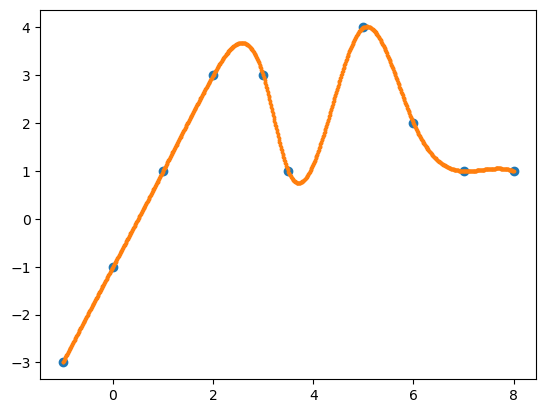

In [6]:
# Cubic spline interpolation
cubic = CubicSpline(xpoints, ypoints)
x_new = np.linspace(xpoints[0], xpoints[-1], 1000)
y_new = cubic(x_new)

# Plot cubic spline
plt.scatter(xpoints, ypoints)
plt.scatter(x_new, y_new, s = 3)

Function values: [0.00 1.50 1.00 0.50 2.00 3.50 3.00 2.50 4.00 5.50 5.00]
x = 5 falls between x = 4.0 and x = 5.0


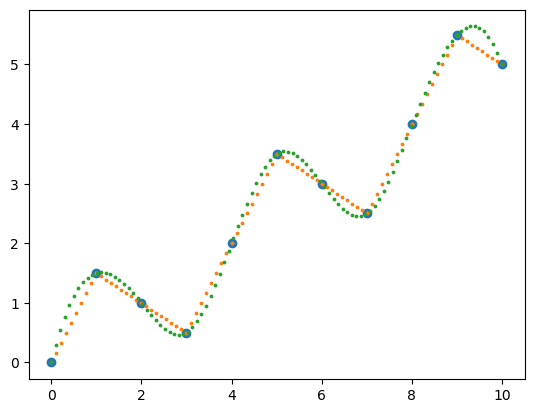

In [7]:
# Create data set for sin function in Q3
integers = np.arange(0, 11, 1.)
y_vals = np.sin((np.pi * integers) / 2) + (integers / 2)
print("Function values:", y_vals)

# Calculate interpolation
g, linearX, linearY = lin_interpolate(integers, y_vals, 5, 10)
cubic = CubicSpline(integers, y_vals)
cubicX = np.linspace(integers[0], integers[-1], 100)
cubicY = cubic(cubicX)

# Plot data and linear plus cubic spline interpolation
plt.scatter(integers, y_vals)
plt.scatter(linearX, linearY, s = 3)
plt.scatter(cubicX, cubicY, s = 3)
plt.show()

C:\Users\jjcal\AppData\Local\Temp\ipykernel_24472\3444017365.py:6: RuntimeWarning: invalid value encountered in divide
  linErr = (linearY - y) / y
C:\Users\jjcal\AppData\Local\Temp\ipykernel_24472\3444017365.py:7: RuntimeWarning: invalid value encountered in divide
  cubicErr = (cubicY - y) / y


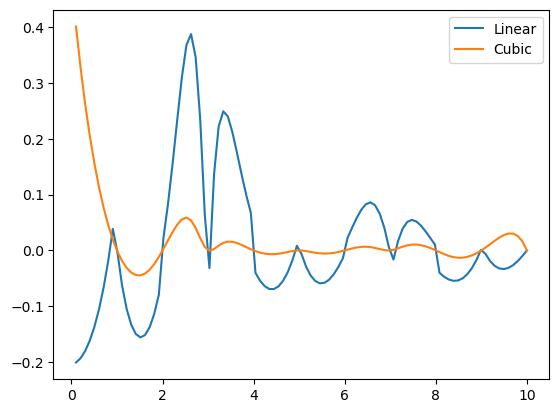

In [ ]:
# Calculate original function and relative errors for both interpolations from [0, 10]
x = np.linspace(0, 10, 100)
y = np.sin((np.pi / 2) * x) + (x / 2)

# Interpolation relative errors
linErr = (linearY - y) / y
cubicErr = (cubicY - y) / y

# Plot relative errors
plt.plot(x, linErr, label = "Linear")
plt.plot(x, cubicErr, label = "Cubic")
plt.legend()

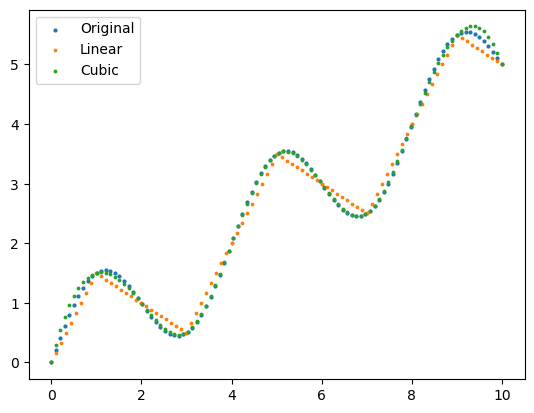

In [22]:
# Plot original function and interpolations
plt.scatter(x, y, s = 4, label = "Original")
plt.scatter(linearX, linearY, s = 3, label = "Linear")
plt.scatter(cubicX, cubicY, s = 3, label = "Cubic")
plt.legend()